# **COVID-19 EDA**

- DATASET usado como base:  COVID-19 Data Analysis with Our World in Data): https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv

## 1\. Contexto

A pandemia da COVID-19, iniciada em 2020, trouxe impactos profundos para a saúde pública, a economia e a vida social em todo o mundo. Durante esse período, governos e organizações de saúde precisaram tomar decisões rápidas baseadas em dados, como restrições de mobilidade, políticas de vacinação e estratégias de mitigação.
O dataset COVID-19 Data Explorer (Our World in Data) reúne informações detalhadas por país, incluindo casos confirmados, óbitos, testagem e vacinação. A análise desses dados permite compreender padrões de evolução da pandemia, comparar diferentes regiões e avaliar os efeitos de políticas públicas adotadas ao longo do tempo.

## 2\. Pacotes e bibliotecas

In [1]:
import io
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

## 3\. Extração

In [2]:
#URL do dataset
url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"

#requisição dos dados
response = requests.get(url)
response.raise_for_status()

#leitura do csv para df
data = pd.read_csv(io.StringIO(response.text))

#informações iniciais
print(data.shape)
print(data.columns[:10])

(535365, 61)
Index(['country', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed',
       'total_cases_per_million', 'new_cases_per_million',
       'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths'],
      dtype='object')


In [3]:
data.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN


## 4\. Transformação

In [4]:
#mapeamento de colunas traduzindo do inglês para português
col_map = {
    "country": "país",
    "date": "data",

    #casos
    "total_cases": "casos_totais",
    "new_cases": "novos_casos",
    "total_cases_per_million": "casos_totais_por_milhao",
    "new_cases_per_million": "novos_casos_por_milhao",

    #mortes
    "total_deaths": "mortes_totais",
    "new_deaths": "novas_mortes",
    "total_deaths_per_million": "mortes_totais_por_milhao",
    "new_deaths_per_million": "novas_mortes_por_milhao",

    #vacinação
    "total_vaccinations": "doses_totais_aplicadas",
    "people_vaccinated": "pessoas_vacinadas_1dose",
    "people_fully_vaccinated": "pessoas_totalmente_vacinadas",
    "new_vaccinations": "novas_doses_aplicadas",
    "total_boosters": "doses_reforco_totais"
}

#seleciona apenas colunas existentes
available_cols = [col for col in col_map.keys() if col in data.columns]

#novo df
df = data[available_cols].copy()
df.rename(columns=col_map, inplace=True)

df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,país,data,casos_totais,novos_casos,casos_totais_por_milhao,novos_casos_por_milhao,mortes_totais,novas_mortes,mortes_totais_por_milhao,novas_mortes_por_milhao,doses_totais_aplicadas,pessoas_vacinadas_1dose,pessoas_totalmente_vacinadas,novas_doses_aplicadas,doses_reforco_totais
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535365 entries, 0 to 535364
Data columns (total 15 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   país                          535365 non-null  object 
 1   data                          535365 non-null  object 
 2   casos_totais                  521655 non-null  float64
 3   novos_casos                   518289 non-null  float64
 4   casos_totais_por_milhao       521655 non-null  float64
 5   novos_casos_por_milhao        518289 non-null  float64
 6   mortes_totais                 521655 non-null  float64
 7   novas_mortes                  519181 non-null  float64
 8   mortes_totais_por_milhao      521655 non-null  float64
 9   novas_mortes_por_milhao       519181 non-null  float64
 10  doses_totais_aplicadas        83222 non-null   float64
 11  pessoas_vacinadas_1dose       79011 non-null   float64
 12  pessoas_totalmente_vacinadas  77011 non-null

In [6]:
#substituindo zeros por NaN em colunas onde zeros podem ser ausência de dados
cols_to_check = [
    "casos_totais", "mortes_totais",
    "doses_totais_aplicadas", "pessoas_vacinadas_1dose",
    "pessoas_totalmente_vacinadas", "doses_reforco_totais"
]

df[cols_to_check] = df[cols_to_check].replace(0.0, np.nan)

#ordenando os dados por país e data
df.sort_values(["país", "data"], inplace=True)

#aplicando ffill para colunas acumuladas
cols_ffill = [
    "casos_totais", "mortes_totais",
    "doses_totais_aplicadas", "pessoas_vacinadas_1dose",
    "pessoas_totalmente_vacinadas", "doses_reforco_totais"
]

df[cols_ffill] = df.groupby("país")[cols_ffill].ffill()

#substitui valores faltantes por 0 apenas para países que nunca reportaram nada
df[cols_ffill] =  df[cols_ffill].fillna(0)

O código:
- Transforma 0.0 em NaN (porque “0 total de vacinados” pode ser falta de dado, não um valor real).

- Ordena por país e data, já que estamos lidando com séries temporais.

- Preenche os buracos com o último valor conhecido (ffill), apenas nas colunas acumuladas (que são monotônicas por natureza).

- Garante que não restem NaN eternos em países que nunca reportaram nada, trocando por 0.

In [7]:
#lista de colunas diárias
cols_diarias = ["novos_casos", "novas_mortes", "novas_doses_aplicadas"]

#cria colunas média movel (7 dias) para cada uma
for col in cols_diarias:
  if col in df.columns:
    df[f"{col}_mm7"] = (
        df.groupby("país")[col]
        .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
    )

#confere o resultado
df[["país", "data"] + [c for c in df.columns if "mm7" in c]].head(15)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,país,data,novos_casos_mm7,novas_mortes_mm7,novas_doses_aplicadas_mm7
0,Afghanistan,2020-01-01,NaN,NaN,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN
5,Afghanistan,2020-01-06,0.0,0.0,NaN
6,Afghanistan,2020-01-07,0.0,0.0,NaN
7,Afghanistan,2020-01-08,0.0,0.0,NaN
8,Afghanistan,2020-01-09,0.0,0.0,NaN
9,Afghanistan,2020-01-10,0.0,0.0,NaN


O código:
- Para cada país, calcula a média dos últimos 7 dias.

- min_periods=1 garante que nos primeiros dias (quando não há 7 registros) ele use a média disponível.

- Cria novas colunas no df, por exemplo:

 - novos_casos_mm7

- novas_mortes_mm7

- novas_doses_aplicadas_mm7

Assim, você terá tanto os valores originais quanto uma versão suavizada, ideal para gráficos e análises de tendência.

**Exemplo:**

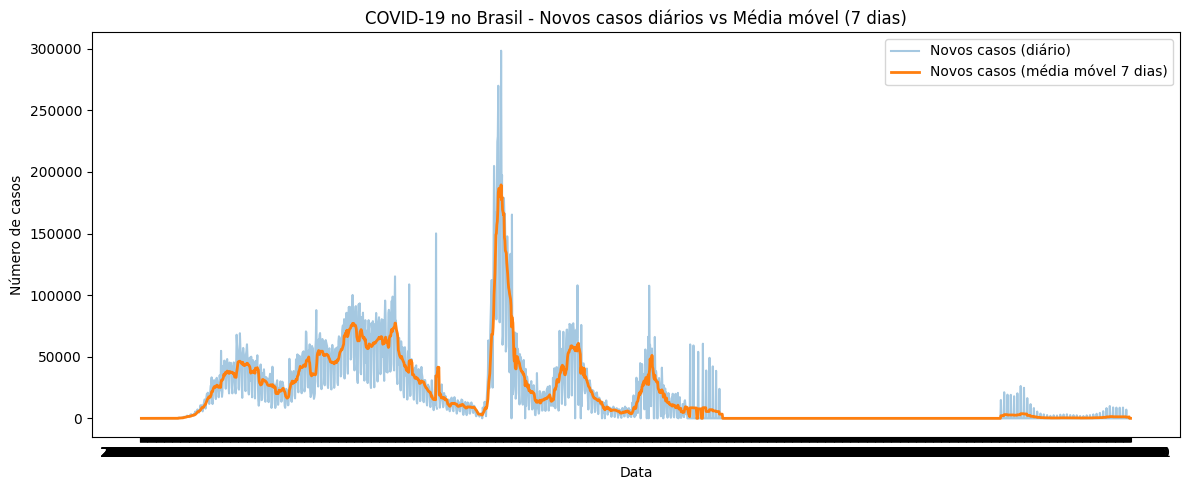

In [8]:
#filtra apenas Brasil
df_brasil = df[df["país"] == "Brazil"].copy()

#plotando novos casos: diários x média móvel
plt.figure(figsize=(12, 5))
plt.plot(df_brasil["data"], df_brasil["novos_casos"],
         label="Novos casos (diário)", alpha=0.4)
plt.plot(df_brasil["data"], df_brasil["novos_casos_mm7"],
         label="Novos casos (média móvel 7 dias)", linewidth=2)

plt.title("COVID-19 no Brasil - Novos casos diários vs Média móvel (7 dias)")
plt.xlabel("Data")
plt.ylabel("Número de casos")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
#facilitando as datas para filtros no looker studio

#converte a coluna 'data' para datetime
df["data"] = pd.to_datetime(df["data"], format="%Y-%m-%d", errors="coerce")

#criar colunas derivadas de data
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.strftime("%B")   # Nome do mês em inglês
df["mes_num"] = df["data"].dt.month        # Número do mês (1-12)
df["ano_mes"] = df["data"].dt.to_period("M").astype(str)

#conferir resultado
df[["data", "ano", "mes", "mes_num", "ano_mes"]].head()


,data,ano,mes,mes_num,ano_mes
0,2020-01-01,2020,January,1,2020-01
1,2020-01-02,2020,January,1,2020-01
2,2020-01-03,2020,January,1,2020-01
3,2020-01-04,2020,January,1,2020-01
4,2020-01-05,2020,January,1,2020-01


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535365 entries, 0 to 535364
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   país                          535365 non-null  object        
 1   data                          535365 non-null  datetime64[ns]
 2   casos_totais                  535365 non-null  float64       
 3   novos_casos                   518289 non-null  float64       
 4   casos_totais_por_milhao       521655 non-null  float64       
 5   novos_casos_por_milhao        518289 non-null  float64       
 6   mortes_totais                 535365 non-null  float64       
 7   novas_mortes                  519181 non-null  float64       
 8   mortes_totais_por_milhao      521655 non-null  float64       
 9   novas_mortes_por_milhao       519181 non-null  float64       
 10  doses_totais_aplicadas        535365 non-null  float64       
 11  pessoas_vacin

## 5\. Carregamento

In [11]:
#salvando para o formato csv sem índice.
df.to_csv("covid19_tratado.csv", index=False)

## Report - Looker Studio
[Covid-19 Report ](https://lookerstudio.google.com/reporting/faa3cf3a-3882-499d-aa32-b2dcd0767ea5)